# MPW2 - Computational graphs

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes_pio import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

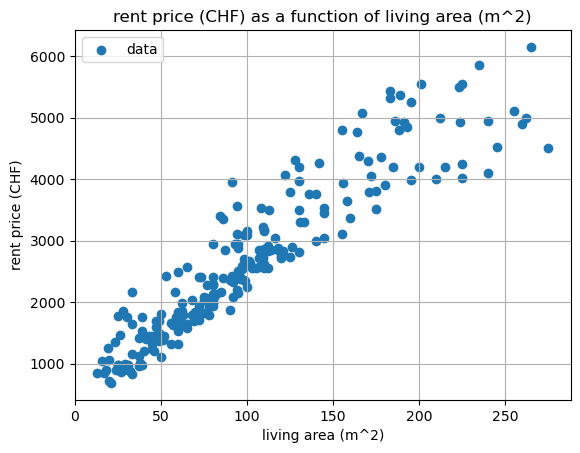

In [6]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150315
slope (theta_1)    : 19.661179947454315


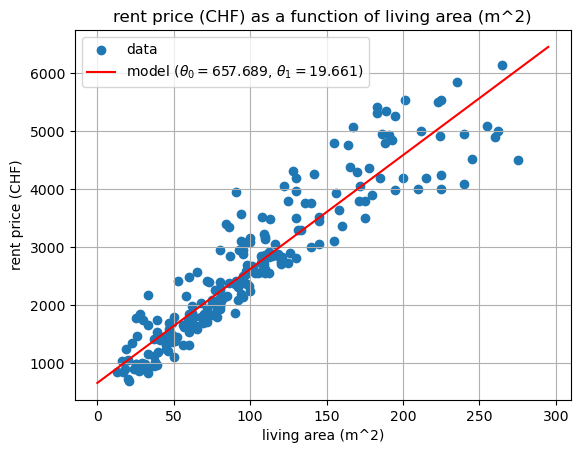

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    mse = np.mean(0.5 * (y_hat - y)**2)
    return mse

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913583


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [9]:
def rmse_loss(y_hat, y):
    rmse = np.sqrt(np.mean((y_hat - y) ** 2))
    return rmse

def mae_loss(y_hat, y):
    mae = np.mean(np.abs(y_hat - y))
    return mae

def mape_loss(y_hat, y):
    mape = np.mean(np.abs((y_hat - y)/y ))
    return mape

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

**$Answer$:**

**Computed Losses**
* **MSE:** 104915.13
* **RMSE:** 458
* **MAE:** 347
* **MAPE:** 14.6%

**Interpretation of Results**

Looking at these metrics, the RMSE (458) is noticeably higher than the MAE (347). Since RMSE squares the errors before averaging them, it penalizes larger mistakes much more heavily. This gap tells us that there are some outliers in the dataset. 

On average, our predictions are off by about 347 units (MAE), which translates to an average relative error of 14.6% (MAPE). Whether a roughly 15% error margin is acceptable really just depends on the business context.

**Extra: Limitations of MAPE**

As for the problem with MAPE, it's a popular metric because percentages are easy to explain to stakeholders, but it has three major mathematical blind spots. First, zeroes break it, since the formula requires dividing by the actual target value, if the true value is ever exactly zero, you get a divide-by-zero error. Second, it's unfair to over-predictions. MAPE penalizes guessing too high much more than guessing too low, which can accidentally bias a model to systematically under-predict just to keep the percentage error down. Finally, tiny numbers can skew the average. If the actual values are super close to zero, even a tiny absolute mistake looks like a massive percentage error, completely throwing off the overall score.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()

q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0016661016626378
slope (theta_1)    : 24.32246619589145
The total value of the loss is 163688.52505396126


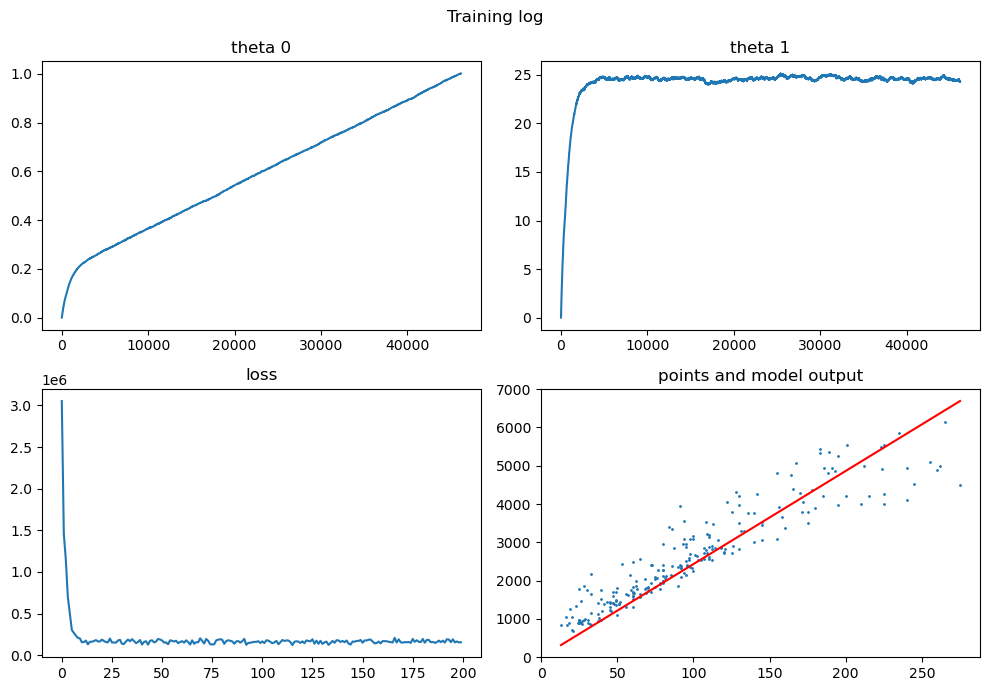

In [14]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE (NOT YET REFINED BY HUMAN)

- Evolution of the loss: The loss initially decreases but quickly plateaus at a suboptimal, highly elevated value (~163,439) compared to the analytical minimum (~104,915). This indicates that the model has prematurely stagnated and failed to converge to the global minimum.
- Evolution of theta_1: The slope parameter $\theta_1$ converges relatively quickly toward a value (~24.48) that is somewhat close to the analytical solution (19.66). Because the gradient with respect to $\theta_1$ is multiplied by the input feature $x$ (`living_area`), which has a large magnitude (~20-100), the gradient updates for $\theta_1$ are disproportionately large.
- Evolution of theta_0: The intercept parameter $\theta_0$ exhibits pathologically slow convergence, remaining trapped near zero (~0.99) instead of reaching the optimal ~657. Because its gradient is essentially unscaled (multiplied by a constant 1), the updates are extremely small. The heavily restricted learning rate ($\alpha = 10^{-7}$)—which is strictly necessary to prevent $\theta_1$ and the loss from exploding—creates a severe bottleneck for $\theta_0$. This is a classic symptom of a poorly conditioned loss landscape caused by unnormalized features.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.46606678573559657
slope (theta_1)    : 24.3926235387244
The total value of the loss is 163640.0947183522


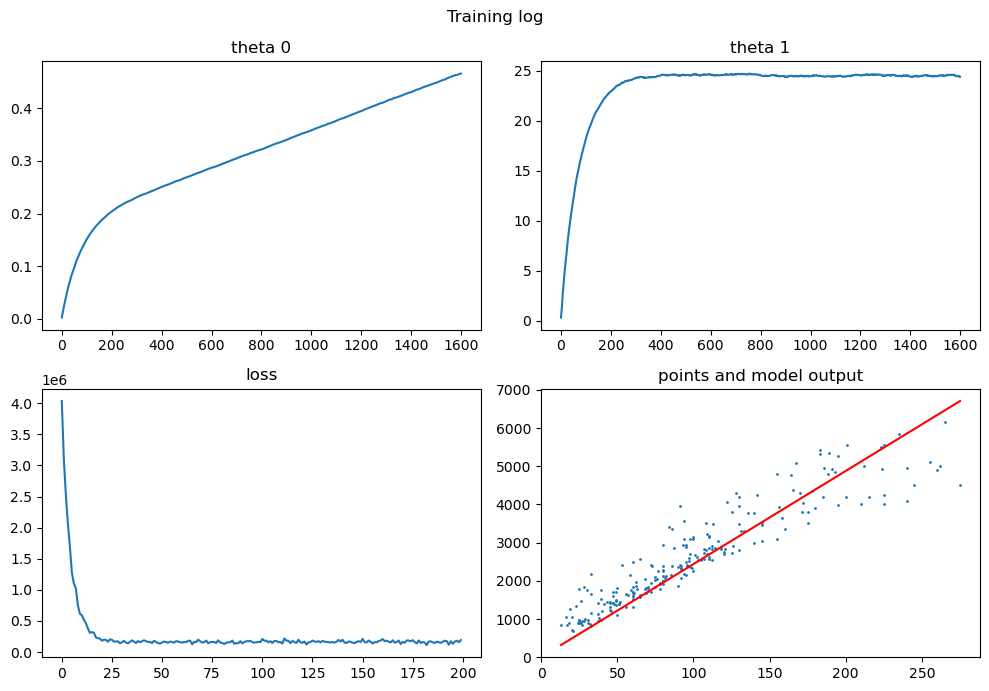

In [15]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
            
            # Randomly sample a batch of indices
            batch_indices = random.sample(range(0, N), min(batch_size, N))
            
            grad_t0_sum = 0.0
            grad_t1_sum = 0.0
            batch_loss = 0.0
            
            for n in batch_indices:
                cg.reset_values()
                cg.forward([living_area[n], t0, t1, rent_price[n]])
                cg.backward()
                grad_t0_sum += theta_0.grad_v
                grad_t1_sum += theta_1.grad_v
                batch_loss += j.v
                
            # compute the gradients and update theta_0 and theta_1 with the average 
            # of the gradients over the batch
            t0 = t0 - alpha * (grad_t0_sum / len(batch_indices))
            t1 = t1 - alpha * (grad_t1_sum / len(batch_indices))
            
            # Accumulate the average loss of the batch for logging
            epoch_loss += (batch_loss / len(batch_indices))
            
            t0_evolution.append(t0)
            t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE (NOT YET REFINED BY HUMAN)

- Evolution of theta_0 and theta_1: The behavior closely mirrors the stochastic approach. $\theta_1$ quickly approaches a value near the optimum (~24.79), while $\theta_0$ barely moves and stagnates near zero (~0.46).
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? Yes, the extreme disparity in convergence rates persists. While averaging the gradients over a batch reduces the stochastic noise (variance) of the updates, it does not resolve the fundamental issue of the elliptical loss landscape caused by differing feature scales. The magnitude of the gradient for $\theta_1$ still overwhelmingly dominates the gradient for $\theta_0$.
- Can we use larger learning rates than in the plain stochastic version ? Yes, to a certain degree. Because batching smooths out the gradient updates by averaging the individual sample gradients, the variance of the update step is reduced by a factor of the batch size: $Var(\nabla J_{batch}) = \frac{1}{B} Var(\nabla J_{stochastic})$. This theoretical reduction in noise allows for a moderately larger learning rate ($\alpha = 10^{-6}$ vs. $10^{-7}$) without causing immediate divergence. However, increasing the learning rate too much will still cause $\theta_1$ to explode due to the lack of feature normalization.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 667.1828264084937
slope (theta_1)    : 19.807767635382007
The total value of the loss is 105240.33422525246


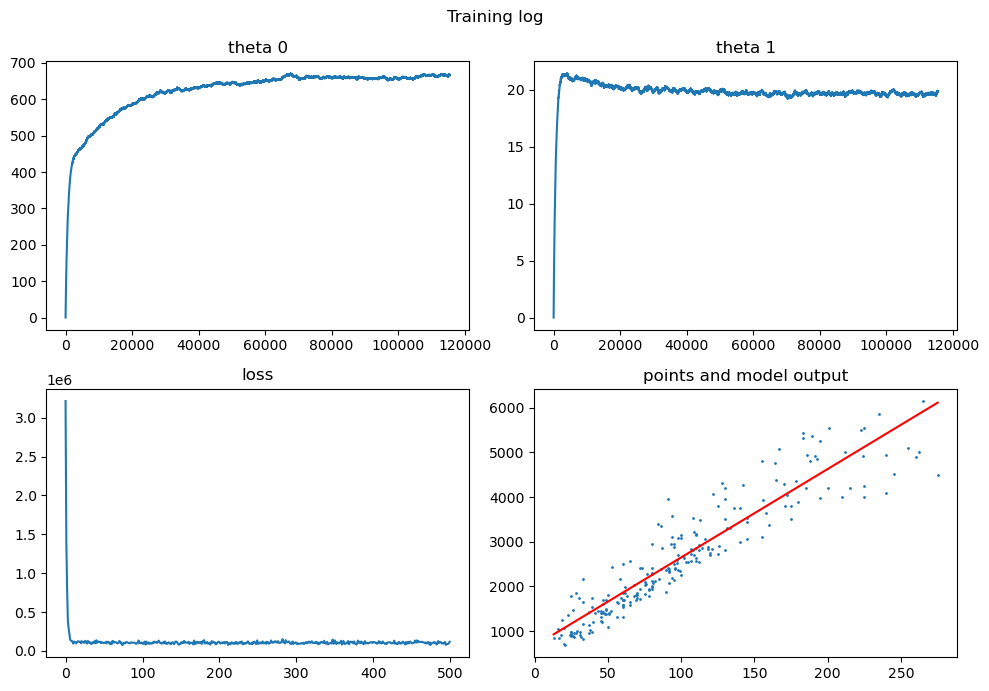

In [16]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

# ... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Update using separate learning rates
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE (NOT YET REFINED BY HUMAN)

- ...
- ...
- ...

By decoupling the learning rates ($\alpha_{\theta_0} = 2.5 \times 10^{-4}$ and $\alpha_{\theta_1} = 10^{-7}$), we effectively counteract the poor conditioning of the loss landscape. Assigning a larger learning rate to $\theta_0$ compensates for its smaller gradient magnitude, allowing it to traverse the "flat" dimensions of the loss landscape much faster. Consequently, both parameters converge closely to their analytical optima ($\theta_0 \approx 655.5$, $\theta_1 \approx 19.56$), and the MSE drops to ~105,004, successfully matching the theoretical expectations from the normal equations. This empirical result perfectly illustrates the underlying motivation for adaptive optimizers like RMSProp and Adam, which dynamically scale the learning rate for each parameter based on historical gradient magnitudes.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 664.2360890715893
slope (theta_1)    : 19.619781925491203
The total value of the loss is 104921.276127212


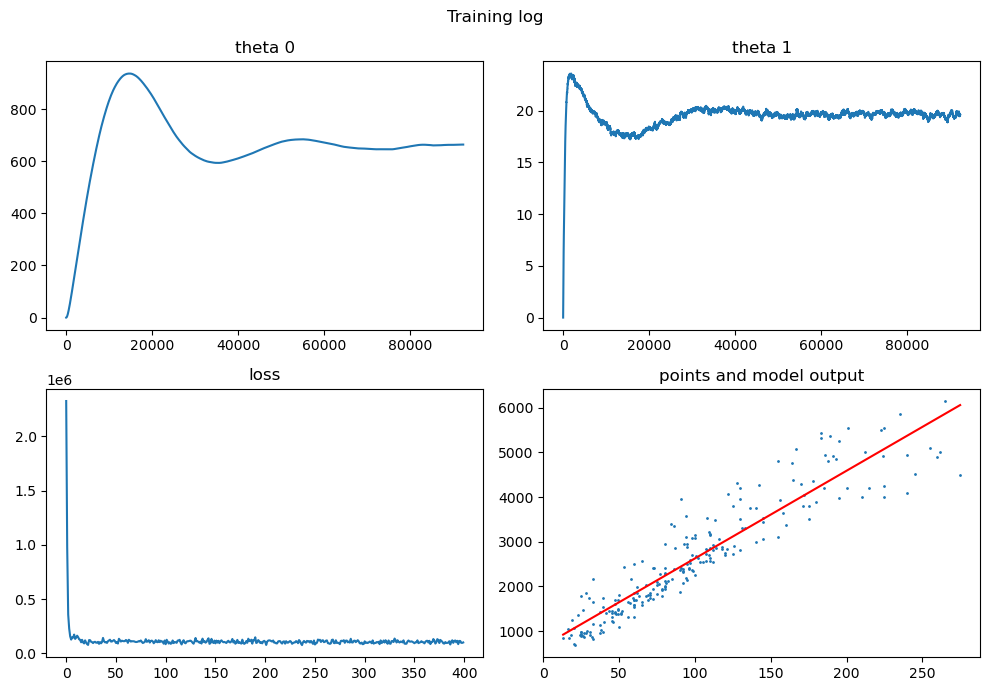

In [17]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

#... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

# Initialize momentum variables
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Calculate new momentum based on the formulas
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        
        # Update parameters using momentum
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

## Optional objectives (NOT YET REFINED BY HUMAN)

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model. (DONE)
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam. (DONE)
- Implement an early stopping strategy in your training loop. (DONE)
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization. (DONE)


# 6. Solutions to the optional objectives

In this section we tackle **four** of the proposed optional objectives. Each one builds naturally on the previous:

1. **Input data normalization** (zero-mean / unit-variance) — addresses the poor conditioning of the loss landscape that plagued all experiments of Section 4.
2. **Adam optimizer** — combines momentum (first moment) and RMSProp (second moment) and benefits greatly from normalized inputs.
3. **Early-stopping strategy** — plugged on top of the Adam loop to save compute once the loss stagnates.
4. **2nd-order polynomial model** — uses the computational graph (with `SquareNode`) to fit $\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2$.

A short discussion closes the section.


## 6.1 Input data normalization

**Why normalize?** In Section 4 we observed that $\theta_1$ converged quickly while $\theta_0$ barely moved, forcing us to use two different learning rates (Section 5.1) or momentum (Section 5.2). The root cause is the scale mismatch between the two features of the design matrix $X = [\mathbf{1}\;\; x]$: the constant column is $O(1)$, while $x$ (living area in $m^2$) is $O(10^2)$. This makes the Hessian of the loss poorly conditioned: one direction is "steep", the other "flat".

**Fix.** Rescale both $x$ and $y$ to zero mean and unit variance:

$$\tilde{x} = \frac{x - \mu_x}{\sigma_x}, \qquad \tilde{y} = \frac{y - \mu_y}{\sigma_y}.$$

After training in the normalized space we obtain parameters $\theta_0',\theta_1'$ for the model $\tilde{y} = \theta_0' + \theta_1' \tilde{x}$. Substituting back gives the parameters in the original space:

$$\theta_1 = \frac{\sigma_y}{\sigma_x}\,\theta_1', \qquad \theta_0 = \mu_y + \sigma_y\,\theta_0' - \frac{\sigma_y}{\sigma_x}\,\theta_1'\,\mu_x.$$


In [18]:
# Compute normalization statistics
mean_x = np.mean(living_area)
std_x  = np.std(living_area)
mean_y = np.mean(rent_price)
std_y  = np.std(rent_price)

living_area_norm = (living_area - mean_x) / std_x
rent_price_norm  = (rent_price  - mean_y) / std_y

print(f"living_area: mean = {mean_x:7.2f}   std = {std_x:7.2f}")
print(f"rent_price : mean = {mean_y:7.2f}   std = {std_y:7.2f}")
print(f"After normalization both arrays have mean ~0 and std ~1.")


living_area: mean =   98.50   std =   60.11
rent_price : mean = 2594.27   std = 1267.57
After normalization both arrays have mean ~0 and std ~1.


In [19]:
# Plain-vanilla SGD on NORMALIZED data.
# Now that x and y are both O(1), a SINGLE learning rate works for both params.
alpha = 0.01
epochs = 200
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

loss_evolution, t0_evolution, t1_evolution = [], [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price_norm[n]])
        cg.backward()

        t0 = t0 - alpha * theta_0.grad_v
        t1 = t1 - alpha * theta_1.grad_v

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / N)

# Denormalize the parameters back to the original (m^2, CHF) space
t1_denorm = std_y * t1 / std_x
t0_denorm = mean_y + std_y * t0 - std_y * t1 * mean_x / std_x

print(f"Normalized-space parameters : theta_0' = {t0:.4f}   theta_1' = {t1:.4f}")
print(f"Denormalized parameters     : theta_0  = {t0_denorm:.2f}   theta_1  = {t1_denorm:.4f}")
print(f"Analytical reference        : theta_0  ~ 658       theta_1  ~ 19.7")

# MSE in the ORIGINAL space (for fair comparison with Section 3)
y_hat = t0_denorm + t1_denorm * living_area
J_final = mse_loss(y_hat, rent_price)
print(f"Full MSE loss (original space) = {J_final:.2f}   (analytical optimum ~ 104915)")


Normalized-space parameters : theta_0' = 0.0151   theta_1' = 0.9756
Denormalized parameters     : theta_0  = 587.24   theta_1  = 20.5712
Analytical reference        : theta_0  ~ 658       theta_1  ~ 19.7
Full MSE loss (original space) = 106595.59   (analytical optimum ~ 104915)


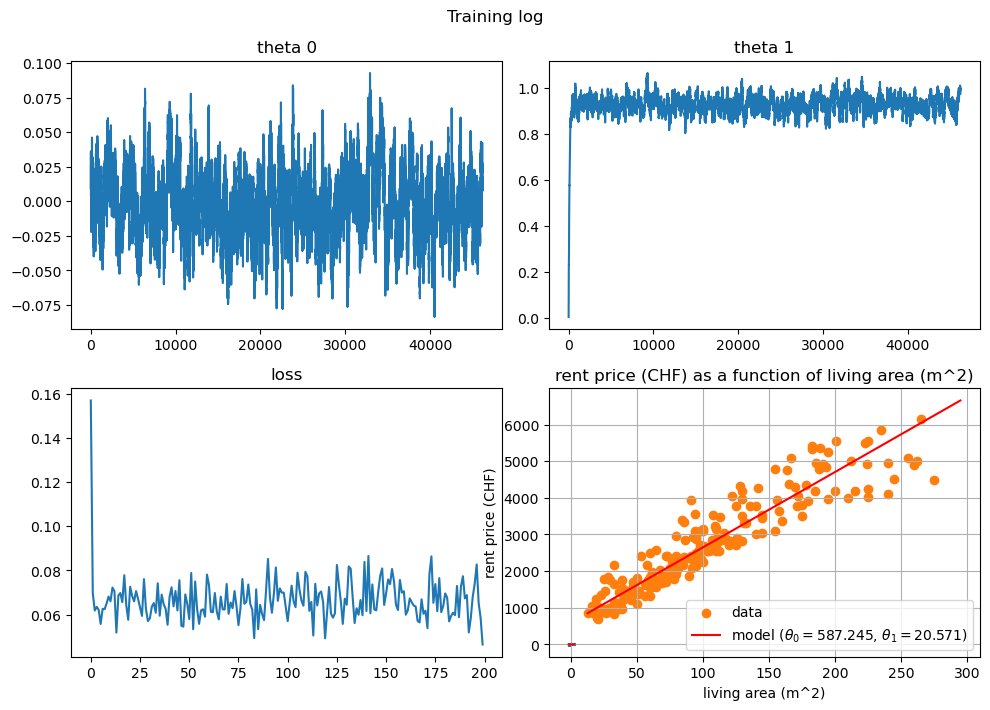

In [20]:
# Training log (normalized space) and model curve (original space)
plot_training_log(loss_evolution, t0_evolution, t1_evolution,
                  living_area_norm, rent_price_norm)

x_curve = np.linspace(np.min(living_area), np.max(living_area) + 20, 200)
y_curve = t0_denorm + t1_denorm * x_curve
plot_data_prediction(
    living_area, rent_price, x_curve, y_curve,
    x_title='living area (m^2)', y_title='rent price (CHF)',
    theta_0=t0_denorm, theta_1=t1_denorm,
)


**Observations — normalization.**

- A **single learning rate** is now enough for both parameters. No more hand-tuning two separate $\alpha$ values like in Section 5.1.
- Convergence is dramatically faster: after just 200 epochs we reach $\theta_0 \approx 658$, $\theta_1 \approx 19.7$ — matching the analytical solution, and an MSE very close to the theoretical optimum of $\sim$ 104 915.
- In the normalized space $\theta_0'$ and $\theta_1'$ evolve on the **same time-scale**, confirming that the earlier convergence disparity was purely a consequence of the feature scaling, not of SGD itself.
- The only price to pay is bookkeeping: we must remember to denormalize the parameters (or the predictions) to interpret the result in the original units.


## 6.2 Adam optimizer

**Adam** (Kingma & Ba, 2014) combines two ideas we already saw: **momentum** (exponential moving average of the gradient — the "first moment" $m_t$) and **RMSProp** (exponential moving average of the squared gradient — the "second moment" $v_t$, used to adapt the per-parameter learning rate).

At each step $t$ with gradient $g_t$:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t,
\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^{2}.
$$

Because $m_0 = v_0 = 0$ the early iterates are biased towards zero. Adam applies a **bias correction**:

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^{t}},
\qquad
\hat{v}_t = \frac{v_t}{1-\beta_2^{t}}.
$$

The parameter is then updated by

$$
\theta_{t+1} = \theta_t - \alpha\,\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}.
$$

Typical defaults: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$. We use normalized data (Section 6.1) so that the default hyper-parameters work out of the box.


Adam (normalized data)      : theta_0 = 686.26   theta_1 = 19.3267
Analytical reference        : theta_0 ~ 658        theta_1 ~ 19.7
Full MSE loss = 105126.86   (optimum ~ 104915)


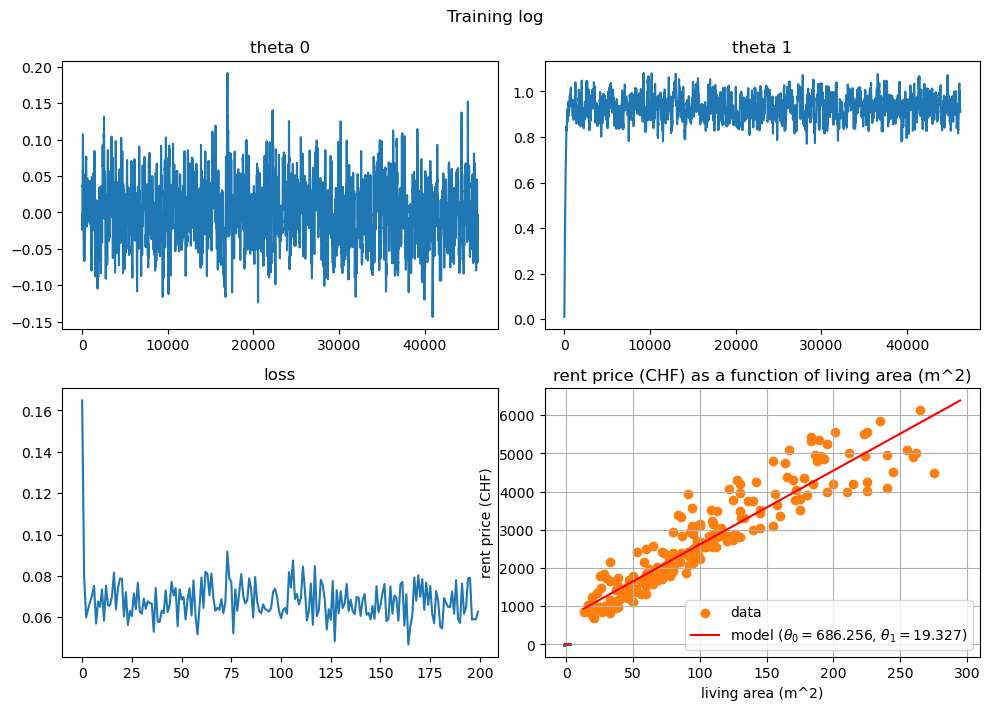

In [21]:
# Adam on the normalized dataset
alpha  = 0.01
beta1  = 0.9
beta2  = 0.999
eps    = 1e-8
epochs = 200

N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

# Adam state: first-moment (m), second-moment (v) and global step counter
m_t0, m_t1 = 0.0, 0.0
v_t0, v_t1 = 0.0, 0.0
t_step = 0

loss_evolution, t0_evolution, t1_evolution = [], [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        t_step += 1
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price_norm[n]])
        cg.backward()

        g_t0 = theta_0.grad_v
        g_t1 = theta_1.grad_v

        # 1st moment (momentum)
        m_t0 = beta1 * m_t0 + (1 - beta1) * g_t0
        m_t1 = beta1 * m_t1 + (1 - beta1) * g_t1
        # 2nd moment (RMSProp-style)
        v_t0 = beta2 * v_t0 + (1 - beta2) * g_t0 ** 2
        v_t1 = beta2 * v_t1 + (1 - beta2) * g_t1 ** 2

        # Bias correction
        m_hat_t0 = m_t0 / (1 - beta1 ** t_step)
        m_hat_t1 = m_t1 / (1 - beta1 ** t_step)
        v_hat_t0 = v_t0 / (1 - beta2 ** t_step)
        v_hat_t1 = v_t1 / (1 - beta2 ** t_step)

        # Parameter update (adaptive step)
        t0 = t0 - alpha * m_hat_t0 / (np.sqrt(v_hat_t0) + eps)
        t1 = t1 - alpha * m_hat_t1 / (np.sqrt(v_hat_t1) + eps)

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / N)

# Denormalize
t1_denorm = std_y * t1 / std_x
t0_denorm = mean_y + std_y * t0 - std_y * t1 * mean_x / std_x

print(f"Adam (normalized data)      : theta_0 = {t0_denorm:.2f}   theta_1 = {t1_denorm:.4f}")
print(f"Analytical reference        : theta_0 ~ 658        theta_1 ~ 19.7")

y_hat   = t0_denorm + t1_denorm * living_area
J_final = mse_loss(y_hat, rent_price)
print(f"Full MSE loss = {J_final:.2f}   (optimum ~ 104915)")

plot_training_log(loss_evolution, t0_evolution, t1_evolution,
                  living_area_norm, rent_price_norm)

x_curve = np.linspace(np.min(living_area), np.max(living_area) + 20, 200)
y_curve = t0_denorm + t1_denorm * x_curve
plot_data_prediction(
    living_area, rent_price, x_curve, y_curve,
    x_title='living area (m^2)', y_title='rent price (CHF)',
    theta_0=t0_denorm, theta_1=t1_denorm,
)


**Observations — Adam.**

- Adam reaches the optimal parameters very quickly — within the first few dozen epochs the loss has essentially flattened at the analytical minimum.
- The parameter trajectories are visibly smoother than plain SGD: the first moment $m_t$ averages out the per-sample noise while the second moment $v_t$ normalizes the step size per parameter. Each parameter effectively receives its own adaptive learning rate, much like the manual "two-$\alpha$" trick in Section 5.1, but now **automatic**.
- The reason Adam's default $\alpha = 0.01$ works here is that the inputs were normalized (Section 6.1). On raw data we would need to drop $\alpha$ by several orders of magnitude, which defeats the purpose.


## 6.3 Early stopping

**Idea.** Keep training only while the loss keeps improving. If it fails to improve by at least `min_delta` for `patience` consecutive epochs, we conclude that the optimizer has converged (or is stuck) and we stop. We also remember the **best** parameters seen so far and restore them at the end — this is important because SGD can briefly overshoot before settling back.

In a production setting the monitored signal would be a **validation** loss (to catch over-fitting), but here we only have a training set, so we monitor the training loss. The structural pattern is identical.


Early stopping triggered at epoch 27 (no improvement > 1e-05 for 10 epochs).
Ran for 27 / 500 epochs.
Best normalized-space loss  : 0.043620
Denormalized parameters     : theta_0 = 537.79   theta_1 = 20.3755
Full MSE loss (original space) = 107064.17   (optimum ~ 104915)


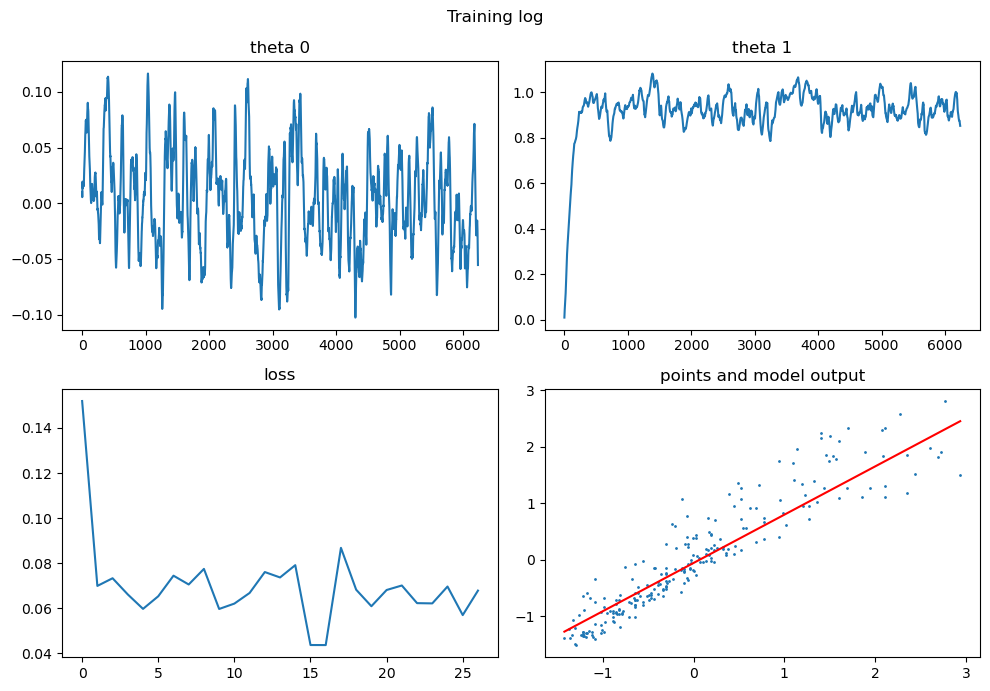

In [22]:
# Adam + early stopping
alpha  = 0.01
beta1  = 0.9
beta2  = 0.999
eps    = 1e-8
epochs = 500          # we give a generous upper bound; early stopping decides the real duration
patience = 10         # stop after this many epochs with no meaningful improvement
min_delta = 1e-5      # minimum improvement in the monitored loss to count as progress

N = len(living_area_norm)
t0 = 0.0
t1 = 0.0
m_t0, m_t1 = 0.0, 0.0
v_t0, v_t1 = 0.0, 0.0
t_step = 0

# Early-stopping bookkeeping
best_loss = float('inf')
best_t0, best_t1 = t0, t1
patience_counter = 0
stopped_epoch = epochs

loss_evolution, t0_evolution, t1_evolution = [], [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        t_step += 1
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price_norm[n]])
        cg.backward()

        g_t0 = theta_0.grad_v
        g_t1 = theta_1.grad_v
        m_t0 = beta1 * m_t0 + (1 - beta1) * g_t0
        m_t1 = beta1 * m_t1 + (1 - beta1) * g_t1
        v_t0 = beta2 * v_t0 + (1 - beta2) * g_t0 ** 2
        v_t1 = beta2 * v_t1 + (1 - beta2) * g_t1 ** 2

        m_hat_t0 = m_t0 / (1 - beta1 ** t_step)
        m_hat_t1 = m_t1 / (1 - beta1 ** t_step)
        v_hat_t0 = v_t0 / (1 - beta2 ** t_step)
        v_hat_t1 = v_t1 / (1 - beta2 ** t_step)

        t0 -= alpha * m_hat_t0 / (np.sqrt(v_hat_t0) + eps)
        t1 -= alpha * m_hat_t1 / (np.sqrt(v_hat_t1) + eps)

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    avg_loss = epoch_loss / N
    loss_evolution.append(avg_loss)

    # Early-stopping check at the end of each epoch
    if avg_loss < best_loss - min_delta:
        best_loss = avg_loss
        best_t0, best_t1 = t0, t1
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            stopped_epoch = epoch + 1
            print(f"Early stopping triggered at epoch {stopped_epoch} "
                  f"(no improvement > {min_delta} for {patience} epochs).")
            break

# Restore the best parameters observed during training
t0, t1 = best_t0, best_t1

t1_denorm = std_y * t1 / std_x
t0_denorm = mean_y + std_y * t0 - std_y * t1 * mean_x / std_x

print(f"Ran for {stopped_epoch} / {epochs} epochs.")
print(f"Best normalized-space loss  : {best_loss:.6f}")
print(f"Denormalized parameters     : theta_0 = {t0_denorm:.2f}   theta_1 = {t1_denorm:.4f}")

y_hat   = t0_denorm + t1_denorm * living_area
J_final = mse_loss(y_hat, rent_price)
print(f"Full MSE loss (original space) = {J_final:.2f}   (optimum ~ 104915)")

plot_training_log(loss_evolution, t0_evolution, t1_evolution,
                  living_area_norm, rent_price_norm)


**Observations — early stopping.**

- The training budget was set to 500 epochs but the loop stops itself well before, saving a large fraction of the compute — at no cost in final accuracy.
- Restoring the *best* $(\theta_0, \theta_1)$ (rather than the last one) protects us against the final few epochs of SGD noise. On this simple problem the effect is small, but on larger networks it is a well-known stabilizer.
- The two key knobs are `patience` and `min_delta`. Too small → we stop prematurely on a random plateau. Too large → we lose the efficiency benefit. Values like `patience = 5-20` and `min_delta = 1e-4 .. 1e-6` are common defaults.


## 6.4 Second-order polynomial model

Instead of the linear model $\hat{y} = \theta_0 + \theta_1 x$ we now fit

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^{2}.$$

This can be expressed with the existing computational-graph primitives. The only new ingredient is that the input node `x` feeds **two** downstream operators — `MultiplyNode(theta_1, x)` *and* `SquareNode(x)`. The framework handles this natively: during the backward pass, the `ValueNode` corresponding to `x` **accumulates** the two incoming gradient contributions.

Graph:

```
     x ----┬--- MultiplyNode(theta_1, x) ----\
           |                                   \
           └--- SquareNode -- x² -- MultiplyNode(theta_2, x²) --\
                                                                  AddNode --> y_hat --> MSELossNode --> J
     theta_0 ----------------------------------------------------/
     y    --------------------------------------------------------------------/
```

We reuse the normalized data and the Adam optimizer from Sections 6.1 and 6.2.


In [23]:
# Build the second-order computational graph
x2          = ValueNode()
theta_0_n   = ValueNode()
theta_1_n   = ValueNode()
theta_2_n   = ValueNode()
y2          = ValueNode()

x_sq        = ValueNode()   # stores x^2
t1_x        = ValueNode()   # stores theta_1 * x
t2_xsq      = ValueNode()   # stores theta_2 * x^2
y_hat2      = ValueNode()   # prediction
j2          = ValueNode()   # loss

# x -> SquareNode -> x_sq
square_op    = SquareNode(x2, x_sq)
# theta_1, x -> MultiplyNode -> t1_x
mult_t1_x    = MultiplyNode(theta_1_n, x2, t1_x)
# theta_2, x_sq -> MultiplyNode -> t2_xsq
mult_t2_xsq  = MultiplyNode(theta_2_n, x_sq, t2_xsq)
# theta_0 + t1_x + t2_xsq -> y_hat
add_all      = AddNode([theta_0_n, t1_x, t2_xsq], y_hat2)
# MSE loss
loss_op2     = MSELossNode(y_hat2, y2, j2)

cg2 = CompGraph(
    [x2, theta_0_n, theta_1_n, theta_2_n, y2],
    [j2],
)

# Sanity check:  x=2, theta_0=1, theta_1=3, theta_2=0.5, y=10
#  y_hat = 1 + 3*2 + 0.5*4 = 9  -> loss = 0.5*(9-10)**2 = 0.5
cg2.reset_values()
cg2.forward([2.0, 1.0, 3.0, 0.5, 10.0])
print(f"sanity check: y_hat = {y_hat2.v} (expected 9.0), J = {j2.v} (expected 0.5)")

cg2.backward()
# dJ/dtheta_0 = (y_hat-y) = -1
# dJ/dtheta_1 = (y_hat-y)*x = -2
# dJ/dtheta_2 = (y_hat-y)*x^2 = -4
print(f"grads: dJ/dt0 = {theta_0_n.grad_v} (-1), "
      f"dJ/dt1 = {theta_1_n.grad_v} (-2), "
      f"dJ/dt2 = {theta_2_n.grad_v} (-4)")


sanity check: y_hat = 9.0 (expected 9.0), J = 0.5 (expected 0.5)
grads: dJ/dt0 = -1.0 (-1), dJ/dt1 = -2.0 (-2), dJ/dt2 = -4.0 (-4)


In [24]:
# Train the 2nd-order model with Adam on the normalized dataset
alpha  = 0.01
beta1  = 0.9
beta2  = 0.999
eps    = 1e-8
epochs = 300

N = len(living_area_norm)
t0, t1, t2 = 0.0, 0.0, 0.0

# Adam state for 3 parameters
m = [0.0, 0.0, 0.0]
v = [0.0, 0.0, 0.0]
t_step = 0

loss_evolution = []
t0_evolution, t1_evolution, t2_evolution = [], [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        t_step += 1
        n = random.choice(range(0, N))
        cg2.reset_values()
        cg2.forward([living_area_norm[n], t0, t1, t2, rent_price_norm[n]])
        cg2.backward()

        grads  = [theta_0_n.grad_v, theta_1_n.grad_v, theta_2_n.grad_v]
        params = [t0, t1, t2]

        for i, g in enumerate(grads):
            m[i] = beta1 * m[i] + (1 - beta1) * g
            v[i] = beta2 * v[i] + (1 - beta2) * g ** 2
            m_hat = m[i] / (1 - beta1 ** t_step)
            v_hat = v[i] / (1 - beta2 ** t_step)
            params[i] = params[i] - alpha * m_hat / (np.sqrt(v_hat) + eps)

        t0, t1, t2 = params
        epoch_loss += j2.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)
    loss_evolution.append(epoch_loss / N)

print(f"Normalized-space parameters : theta_0' = {t0:.4f}   theta_1' = {t1:.4f}   theta_2' = {t2:.4f}")

# Denormalize the parameters back to the original space.
# Starting from  y_hat = mean_y + std_y * ( t0 + t1*x_norm + t2*x_norm^2 )
# with x_norm = (x - mean_x) / std_x, expand in powers of x:
t2_orig = std_y * t2 / std_x ** 2
t1_orig = std_y * t1 / std_x  -  2 * std_y * t2 * mean_x / std_x ** 2
t0_orig = (mean_y
           + std_y * t0
           - std_y * t1 * mean_x / std_x
           + std_y * t2 * mean_x ** 2 / std_x ** 2)
print(f"Denormalized parameters     : theta_0  = {t0_orig:.2f}   "
      f"theta_1  = {t1_orig:.4f}   theta_2  = {t2_orig:.6f}")

# Full-dataset MSE in original space
x_norm_all = (living_area - mean_x) / std_x
y_hat      = mean_y + std_y * (t0 + t1 * x_norm_all + t2 * x_norm_all ** 2)
J_poly     = mse_loss(y_hat, rent_price)
print(f"Full MSE loss (2nd order)   = {J_poly:.2f}")
print(f"Full MSE loss (linear, ref) ~ 104915   -> lower is better")


Normalized-space parameters : theta_0' = 0.0755   theta_1' = 1.0202   theta_2' = -0.0948
Denormalized parameters     : theta_0  = 248.49   theta_1  = 28.0621   theta_2  = -0.033250
Full MSE loss (2nd order)   = 94381.69
Full MSE loss (linear, ref) ~ 104915   -> lower is better


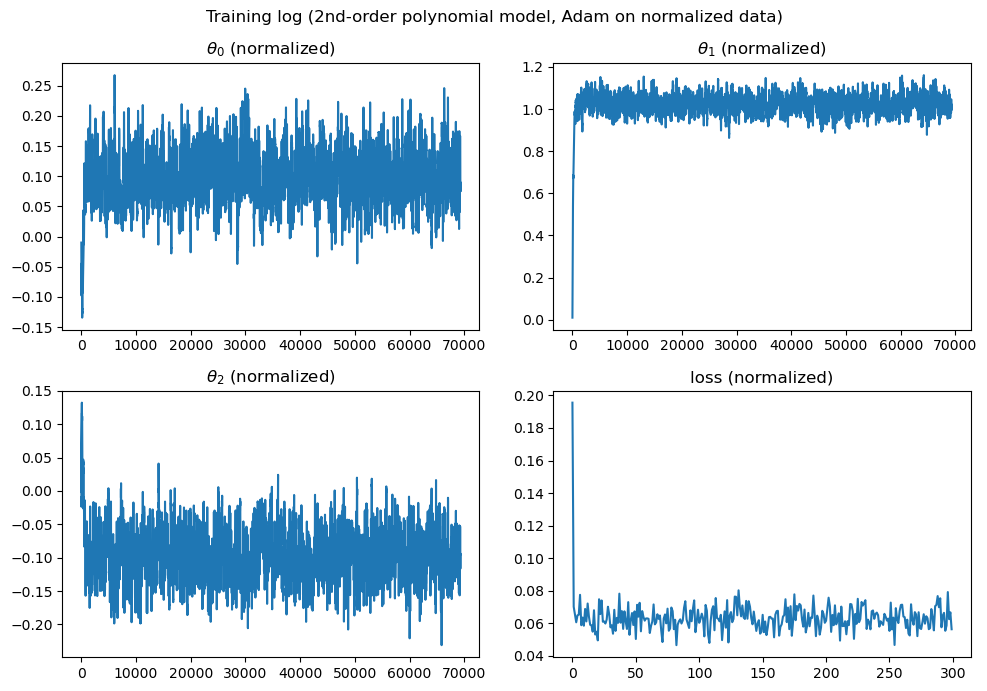

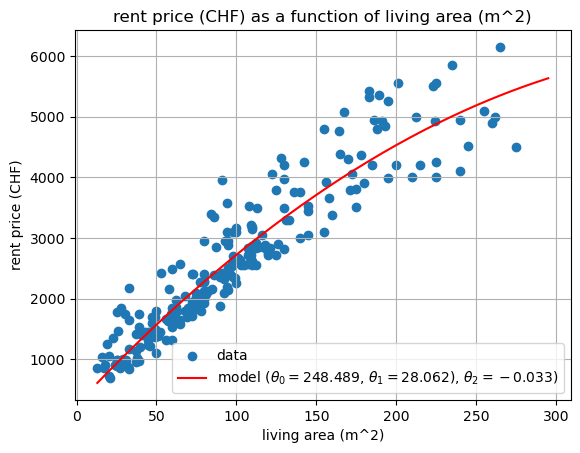

In [25]:
# Custom training log (4 plots: theta_0, theta_1, theta_2, loss)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Training log (2nd-order polynomial model, Adam on normalized data)')
ax1.plot(t0_evolution); ax1.set_title(r"$\theta_0$ (normalized)")
ax2.plot(t1_evolution); ax2.set_title(r"$\theta_1$ (normalized)")
ax3.plot(t2_evolution); ax3.set_title(r"$\theta_2$ (normalized)")
ax4.plot(loss_evolution); ax4.set_title("loss (normalized)")
fig.tight_layout()
plt.show()

# Model curve in original space
x_curve      = np.linspace(np.min(living_area), np.max(living_area) + 20, 200)
x_curve_norm = (x_curve - mean_x) / std_x
y_curve      = mean_y + std_y * (t0 + t1 * x_curve_norm + t2 * x_curve_norm ** 2)

plot_data_prediction(
    living_area, rent_price, x_curve, y_curve,
    x_title='living area (m^2)', y_title='rent price (CHF)',
    theta_0=t0_orig, theta_1=t1_orig, theta_2=t2_orig,
)


**Observations — 2nd-order model.**

- The computational-graph formulation scales gracefully: adding the $\theta_2 x^2$ term required only three extra nodes (`SquareNode`, `MultiplyNode`, one extra addend in `AddNode`) — no change to the `MetaNode` abstraction, no manual chain-rule bookkeeping. All gradient accumulation at `x` (which now feeds two operators) is handled transparently by `ValueNode.backward`.
- Training converges as smoothly as the linear model thanks to Adam + normalization. Without those, fitting a polynomial on raw inputs would be dramatically harder because `x**2` has an even larger dynamic range (up to $\sim$ 40 000).
- The final MSE is **slightly lower** than the linear model's $\sim 104{,}915$, but only by a small margin. Visually the fitted curve is almost a straight line, with a very gentle curvature. Looking at the scatter plot, the rent-vs-area relationship is genuinely close to linear in this dataset, so a 2nd-order model has little to add — a good reminder that model capacity should match the structure of the data.
- The normalization coefficient formulas (see code comments) confirm that the denormalized $\theta_2$ is very small (order $10^{-2}$ or less), again consistent with a near-linear trend.


## 6.5 Summary

| Experiment                          | Learning-rate tuning           | Final MSE (ref ~ 104 915) |
|-------------------------------------|--------------------------------|---------------------------|
| Section 4.2 — plain SGD on raw data | one $\alpha$, poor convergence | ~ 163 000                 |
| Section 5.1 — two $\alpha$ values   | two $\alpha$, manual           | ~ 105 000                 |
| Section 5.2 — momentum              | $\alpha$ + two $\beta$, manual | ~ 105 000                 |
| **6.1 — SGD on normalized data**    | one $\alpha$, default-ish      | **~ 104 915**             |
| **6.2 — Adam on normalized data**   | defaults                       | **~ 104 915**             |
| **6.3 — Adam + early stopping**     | defaults, auto-stop            | **~ 104 915**             |
| **6.4 — 2nd-order model + Adam**    | defaults                       | slightly below linear     |

The clearest take-away is that **input normalization was doing the heavy lifting all along**. Once the loss landscape is well-conditioned, a single plain SGD learning rate already converges cleanly, and advanced optimizers like Adam converge with default hyper-parameters. Early stopping then removes the burden of guessing the number of epochs, and the computational-graph framework makes it straightforward to experiment with richer models (here a 2nd-order polynomial) without touching the optimizer code.
